In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

from datetime import datetime, timedelta
from random import randint, random, seed

import matplotlib.pyplot as plt
import seaborn as sns

from engines import GAMealPlanner, get_pantry_ingredient, load_all_ingredients, make_preferences
from models import (
    MealPlanningEnvironment,
    Pantry,
)

In [2]:
seed(1)

In [3]:
preferences = make_preferences()

In [4]:
all_ingredients = load_all_ingredients("../recipe_extraction/supplemented_structured_ingredients.json")

In [5]:
CURRENT_DATE = datetime.now()

In [6]:
pantry_ingredient_name_by_quantity = {
    "chicken breast": 800,
    "broccoli": 1500,
    "rice": 1000,
}

In [7]:
pantry_ingredients = [
    get_pantry_ingredient(name, CURRENT_DATE + timedelta(days=randint(1, 7)), all_ingredients)
    for name in pantry_ingredient_name_by_quantity.keys()
]

In [8]:
pantry_ingredient_by_quantity = dict(zip(pantry_ingredients, pantry_ingredient_name_by_quantity.values()))

In [9]:
pantry = Pantry()

for pantry_ingredient, quantity in pantry_ingredient_by_quantity.items():
    pantry.add(
        pantry_ingredient,
        quantity,
    )

In [10]:
pantry.print()

---
Quantity: 800 g
Ingredient: chicken breast
	Estimated Expiration Date: 2026-05-05
	Nutritional Information:
		Calories: 125.0 kcal
		Carbohydrates: 1.79 g
		Sugar: 0.0 g
		Protein: 16.07 g
		Fat: 5.36 g
		Saturated Fat: 1.79 g
		Fiber: 1.8 g
		Sodium: 571.0 mg
		Gluten Free: Yes
		Lactose Free: Yes
		Vegetarian: No
		Vegan: No
---
---
Quantity: 1500 g
Ingredient: broccoli
	Estimated Expiration Date: 2026-05-08
	Nutritional Information:
		Calories: 31.0 kcal
		Carbohydrates: 6.27 g
		Sugar: 1.4 g
		Protein: 2.57 g
		Fat: 0.34 g
		Saturated Fat: 0.039 g
		Fiber: 2.4 g
		Sodium: 36.0 mg
		Gluten Free: Yes
		Lactose Free: Yes
		Vegetarian: Yes
		Vegan: Yes
---
---
Quantity: 1000 g
Ingredient: rice
	Estimated Expiration Date: 2026-05-10
	Nutritional Information:
		Calories: 356.0 kcal
		Carbohydrates: 80.0 g
		Sugar: 0.0 g
		Protein: 6.67 g
		Fat: 0.0 g
		Saturated Fat: 0.0 g
		Fiber: 2.2 g
		Sodium: 0.0 mg
		Gluten Free: Yes
		Lactose Free: Yes
		Vegetarian: Yes
		Vegan: Yes
---


In [11]:
meal_planning_environment = MealPlanningEnvironment(
    recipes=[],
    pantry=pantry,
    preferences=preferences,
)

In [12]:
meal_planning_environment.load_recipes_from_json("../recipe_extraction/supplemented_structured_recipes.json")

In [13]:
all_ingredient_names = []

for recipe in meal_planning_environment.recipes:
    for ingredient_name in recipe.ingredients.keys():
        all_ingredient_names.append(ingredient_name)

In [14]:
all_ingredient_costs = {}

for ingredient_name in sorted(set(all_ingredient_names)):
    all_ingredient_costs[ingredient_name] = random()

In [15]:
meal_planning_environment.ingredient_costs = all_ingredient_costs
meal_planning_environment._check_ingredient_costs()

In [16]:
planner = GAMealPlanner(meal_planning_environment)

In [17]:
NUM_GENERATIONS = 500
NUM_PARENTS_MATING = 20
POPULATION_SIZE = 100
NUM_DAYS = 7
NUM_MEALS_PER_DAY = 3
GENERATION_PRINT_INTERVAL = 50
SEED = 1

In [18]:
best_meal_plan, best_fitness_score = planner.generate_meal_plan(
    num_days=NUM_DAYS,
    meals_per_day=NUM_MEALS_PER_DAY,
    num_generations=NUM_GENERATIONS,
    num_parents_mating=NUM_PARENTS_MATING,
    population_size=POPULATION_SIZE,
    generation_print_interval=GENERATION_PRINT_INTERVAL,
    seed=SEED,
)

Generation 50, Best Fitness: -0.49
Generation 100, Best Fitness: -0.43
Generation 150, Best Fitness: -0.41
Generation 200, Best Fitness: -0.41
Generation 250, Best Fitness: -0.40
Generation 300, Best Fitness: -0.25
Generation 350, Best Fitness: -0.23
Generation 400, Best Fitness: -0.22
Generation 450, Best Fitness: -0.21
Generation 500, Best Fitness: -0.21


In [19]:
print(f"Best fitness score: {best_fitness_score:.2f}")

Best fitness score: -0.21


In [20]:
sns.set_theme("notebook")
colours = sns.color_palette("husl", NUM_GENERATIONS + 1)

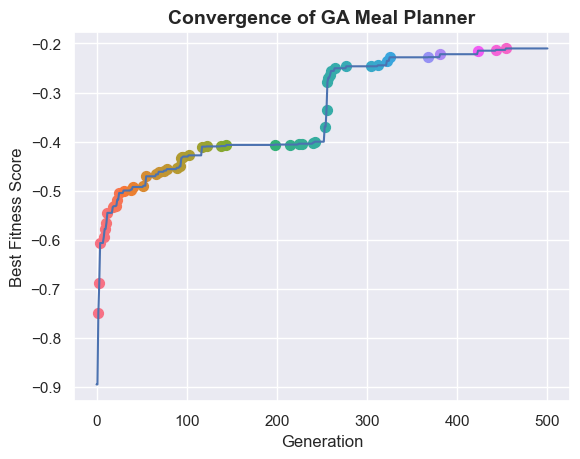

In [21]:
convergence_values = planner.ga_instance.best_solutions_fitness

plt.plot(convergence_values)

for i in range(1, len(convergence_values)):
    if convergence_values[i] != convergence_values[i - 1]:
        plt.scatter(i, convergence_values[i], color=colours[i], s=50)

plt.title("Convergence of GA Meal Planner", fontsize=14, fontweight="bold")
plt.xlabel("Generation")
plt.ylabel("Best Fitness Score")
plt.show()

In [22]:
pantry_consumption_df = planner.get_pantry_consumption()
pantry_consumption_df

,Ingredient,Available,Consumed,Unused,Expires in
0,chicken breast,800,0.0,800.0,1d
1,broccoli,1500,1500.0,0.0,4d
2,rice,1000,0.0,1000.0,6d


In [23]:
meal_plan_df = planner.get_meal_plan_recipes()
meal_plan_df

,Day,Meal 1,Meal 2,Meal 3
0,1,Hot and Sticky Apricot-Glazed Chicken,"Wild Mushrooms, Shallot and Gruyère Omelets",Broccoli with Garlic and Parmesan Cheese
1,2,Toasted Jalapeño Corn Bread,Broccoli with Toasted Garlic Crumbs,To Zest Citrus Fruits
2,3,Ginger Molasses Lace Cookies,"Linguine with Broccoli, Pine Nuts, and Red Pep...",Tequila Sunrise
3,4,Sante Fe Chicken,Fried Calamari with Peperoncini Mayonnaise,Bittersweet Chocolate Irish Whiskey Cake
4,5,Roast Chicken With Harissa And Schmaltz,Bing Cherry Clafouti,Rouille
5,6,Raspberry and Blueberry Vanilla Cheesecake,Scallion Rice,Spaghetti with Anchovy Olive Sauce
6,7,Bittersweet Chocolate and Almond Cake,Lemon Fettuccine with Asparagus and Salmon Caviar,Matzo Balls


In [24]:
shopping_list_df, num_ingredients, total_cost = planner.get_shopping_list()

print(f"Total ingredients needed to purchase: {num_ingredients}")
print(f"Total cost: €{total_cost:.2f}")

shopping_list_df

Total ingredients needed to purchase: 106
Total cost: €40.09


,Ingredient,Quantity to Buy (g),Cost (€)
0,Bing cherries,22.6,0.20
1,Gruyère cheese,11.1,0.04
2,Irish whiskey,3.4,0.00
3,Mexican-style stewed tomatoes,33.7,0.24
4,Parmesan cheese,70.8,0.03
...,...,...,...
102,white part of scallion,26.3,0.09
103,white wine vinegar,14.8,0.15
104,yam,33.3,0.13
105,yellow cornmeal,9.0,0.06


In [25]:
daily_nutrition_df = planner.get_daily_nutrition()
daily_nutrition_df

,Calories,Protein,Δ Calories and Target Calories,Δ Protein and Target Protein
Day 1,1864.6 kcal,51.7 g,-135.4 kcal,1.7 g
Day 2,2023.5 kcal,69.5 g,23.5 kcal,19.5 g
Day 3,2408.8 kcal,75.4 g,408.8 kcal,25.4 g
Day 4,1984.3 kcal,49.1 g,-15.7 kcal,-0.9 g
Day 5,2009.0 kcal,49.5 g,9.0 kcal,-0.5 g
Day 6,1996.8 kcal,46.7 g,-3.2 kcal,-3.3 g
Day 7,1971.0 kcal,49.4 g,-29.0 kcal,-0.6 g
